<a href="https://colab.research.google.com/github/Mangesh0309/BE-SPPU/blob/main/Assignment3DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST Clothing classification using CNN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape: ", X_train.shape)
print("testing data shape: ", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape:  (60000, 28, 28)
testing data shape:  (10000, 28, 28)


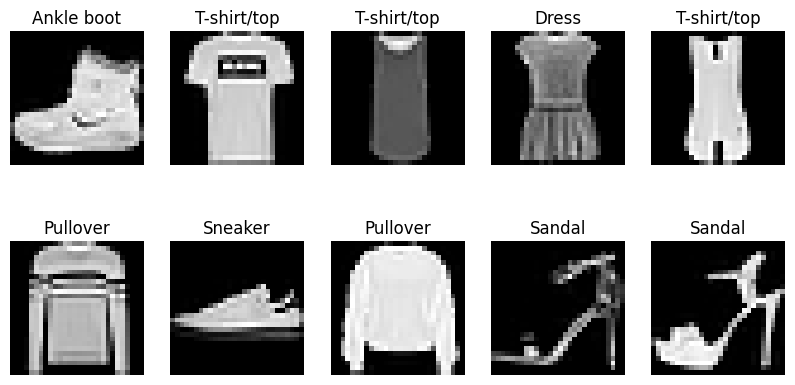

In [15]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(class_names[y_train[i]])
  plt.axis('off')
plt.show()

In [16]:
X_train = X_train/255.0
X_test = X_test/255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One Hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [17]:
model = Sequential()

# Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

#Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])


In [19]:
history = model.fit(X_train, y_train,
                    epochs=8,
                    batch_size=128,
                    validation_data=(X_test, y_test))


Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 102ms/step - accuracy: 0.7586 - loss: 0.6659 - val_accuracy: 0.8430 - val_loss: 0.4388
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - accuracy: 0.8454 - loss: 0.4319 - val_accuracy: 0.8671 - val_loss: 0.3669
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.8631 - loss: 0.3795 - val_accuracy: 0.8707 - val_loss: 0.3519
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.8740 - loss: 0.3474 - val_accuracy: 0.8856 - val_loss: 0.3124
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.8834 - loss: 0.3238 - val_accuracy: 0.8890 - val_loss: 0.2981
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.8893 - loss: 0.3022 - val_accuracy: 0.8976 - val_loss: 0.2868
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.8947 - loss: 0.2861 - val_accuracy: 0.8951 - val_loss: 0.2800
Epoch 8/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9027 - loss: 0.2704 - val_a

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy: ", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8977 - loss: 0.2736
Test accuracy:  0.8977000117301941


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


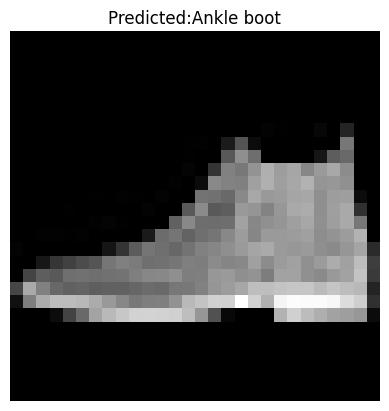

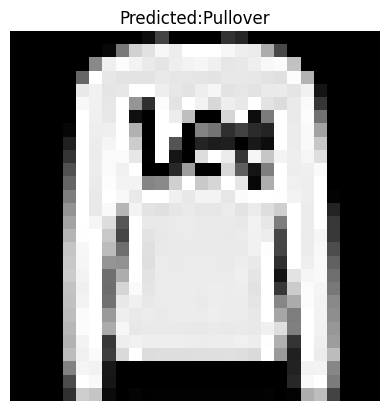

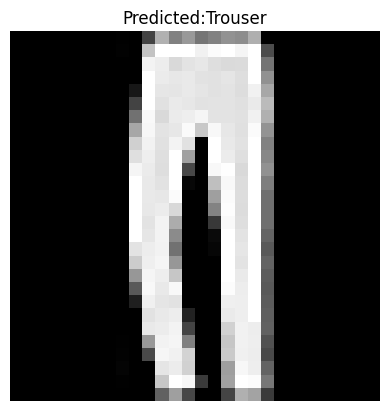

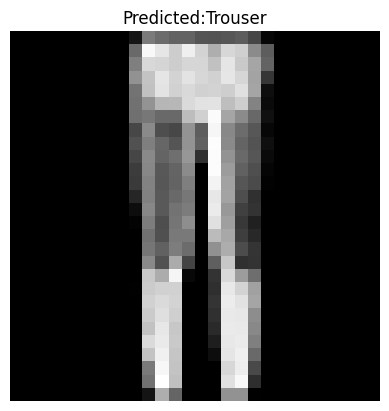

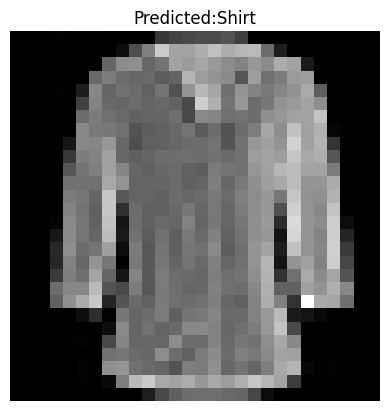

In [21]:
predictions = model.predict(X_test)

for i in range(5):
  plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
  plt.title("Predicted:" + class_names[np.argmax(predictions[i])])
  plt.axis('off')
  plt.show()

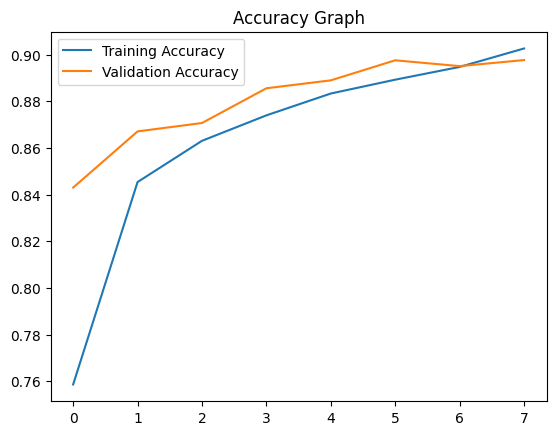

In [22]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()
